In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [3]:
matches.head(2)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN


In [4]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,1.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,2.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [5]:
matches.sample()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
562,563,2015,Chennai,2015-05-10,Chennai Super Kings,Rajasthan Royals,Chennai Super Kings,bat,normal,0,Chennai Super Kings,12,0,RA Jadeja,"MA Chidambaram Stadium, Chepauk",M Erasmus,CK Nandan,NaN


In [6]:
deliveries.sample()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
6461,28,1,Rising Pune Supergiant,Mumbai Indians,4.0,6.0,AM Rahane,RA Tripathi,KV Sharma,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN


In [7]:
matches.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [8]:
matches[['city','winner','player_of_match','umpire1','umpire2','umpire3']]  # # These columns have null values in matches

,city,winner,player_of_match,umpire1,umpire2,umpire3
0,Hyderabad,Sunrisers Hyderabad,Yuvraj Singh,AY Dandekar,NJ Llong,NaN
1,Pune,Rising Pune Supergiant,SPD Smith,A Nand Kishore,S Ravi,NaN
2,Rajkot,Kolkata Knight Riders,CA Lynn,Nitin Menon,CK Nandan,NaN
3,Indore,Kings XI Punjab,GJ Maxwell,AK Chaudhary,C Shamshuddin,NaN
4,Bangalore,Royal Challengers Bangalore,KM Jadhav,NaN,NaN,NaN
...,...,...,...,...,...,...
751,Mumbai,Mumbai Indians,HH Pandya,Nanda Kishore,O Nandan,S Ravi
752,Chennai,Mumbai Indians,AS Yadav,Nigel Llong,Nitin Menon,Ian Gould
753,Visakhapatnam,Delhi Capitals,RR Pant,NaN,NaN,NaN
754,Visakhapatnam,Chennai Super Kings,F du Plessis,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin


In [9]:
matches.shape

(756, 18)

In [10]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [11]:
matches['season'].value_counts() # matches per season

,count
season,
2013,76
2012,74
2011,73
2010,60
2016,60
2018,60
2019,60
2014,60
2017,59


In [12]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30706 entries, 0 to 30705
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          30706 non-null  int64  
 1   inning            30706 non-null  int64  
 2   batting_team      30706 non-null  object 
 3   bowling_team      30706 non-null  object 
 4   over              30705 non-null  float64
 5   ball              30705 non-null  float64
 6   batsman           30705 non-null  object 
 7   non_striker       30705 non-null  object 
 8   bowler            30705 non-null  object 
 9   is_super_over     30705 non-null  float64
 10  wide_runs         30705 non-null  float64
 11  bye_runs          30705 non-null  float64
 12  legbye_runs       30705 non-null  float64
 13  noball_runs       30705 non-null  float64
 14  penalty_runs      30705 non-null  float64
 15  batsman_runs      30705 non-null  float64
 16  extra_runs        30705 non-null  float6

In [13]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,1
ball,1
batsman,1
non_striker,1
bowler,1
is_super_over,1


In [14]:
deliveries[['player_dismissed','dismissal_kind','fielder']] # These columns have null values in deliveries

,player_dismissed,dismissal_kind,fielder
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
30701,NaN,NaN,NaN
30702,NaN,NaN,NaN
30703,NaN,NaN,NaN
30704,NaN,NaN,NaN


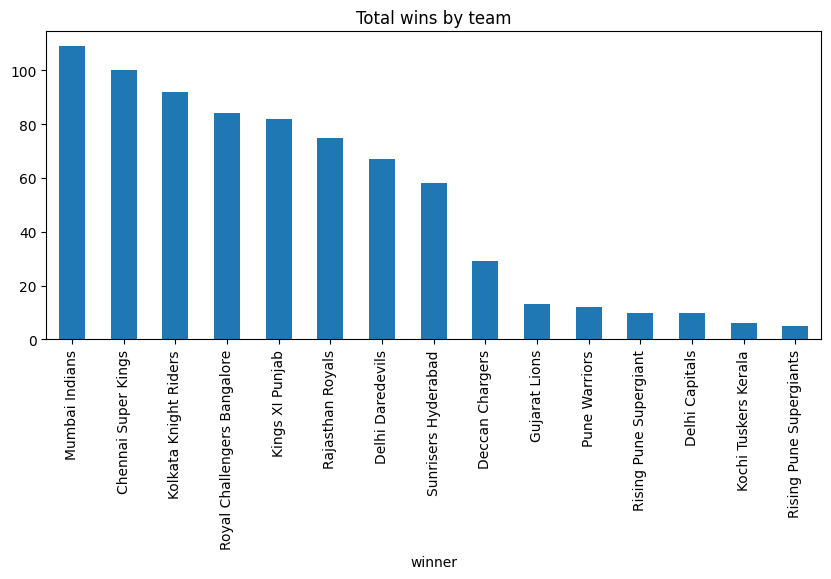

In [16]:
# 1. Most successful teams

matches['winner'].value_counts().plot(kind = 'bar', figsize = (10,4))
plt.title('Total wins by team')
plt.show()

In [17]:
# 2. Toss impact

toss_win = matches[matches['toss_winner'] == matches['winner']]
print(f"Toss winner also won match : {len(toss_win)/len(matches)*100:.1f}%")

Toss winner also won match : 52.0%


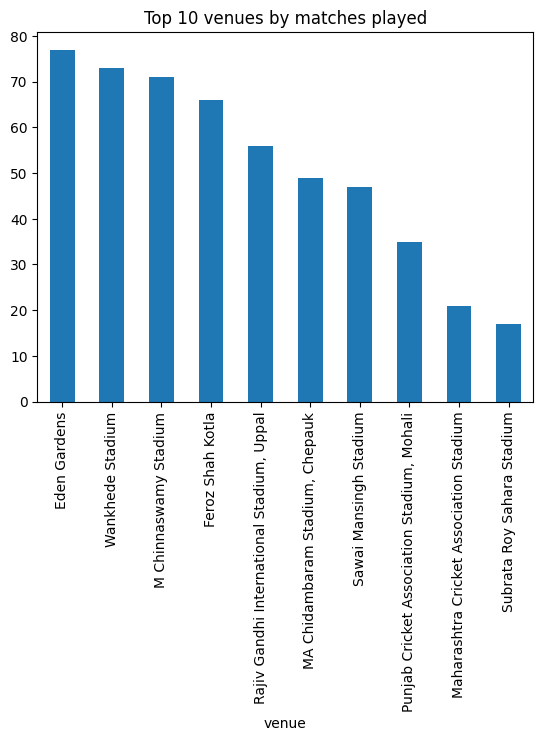

In [18]:
# 3. Wins by venue
matches.groupby('venue')['winner'].count().sort_values(ascending=False)[:10].plot(kind = 'bar')
plt.title('Top 10 venues by matches played')
plt.show()

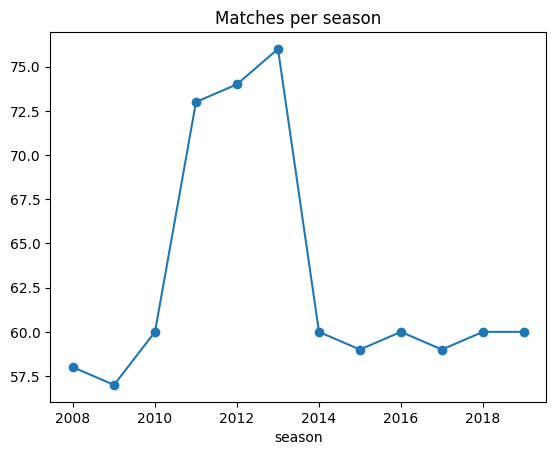

In [19]:
# 4. Season-wise matches
matches['season'].value_counts().sort_index().plot(kind = 'line',marker = 'o')
plt.title('Matches played per season')
plt.title('Matches per season')
plt.show()

# Feature engineering

In [20]:
# Select relevant columns
cols = ['team1','team2','city','toss_winner','toss_decision','winner','season']
df = matches[cols].dropna()

In [23]:
df.head()

,team1,team2,city,toss_winner,toss_decision,winner,season,target,toss_winner_is_team1
0,Sunrisers Hyderabad,Royal Challengers Bangalore,Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,2017,1,0
1,Mumbai Indians,Rising Pune Supergiant,Pune,Rising Pune Supergiant,field,Rising Pune Supergiant,2017,0,0
2,Gujarat Lions,Kolkata Knight Riders,Rajkot,Kolkata Knight Riders,field,Kolkata Knight Riders,2017,0,0
3,Rising Pune Supergiant,Kings XI Punjab,Indore,Kings XI Punjab,field,Kings XI Punjab,2017,0,0
4,Royal Challengers Bangalore,Delhi Daredevils,Bangalore,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,2017,1,1


In [21]:
# Create target column : 1 if team1 won, 0 if team2 won
df['target'] = (df['winner'] == df['team1']).astype(int)

In [50]:
# Feature: toss winner team?
df['toss_winner_is_team1'] = (df['toss_winner'] == df['team1']).astype(int)

In [37]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

# Create encoders
le_teams = LabelEncoder()
le_city  = LabelEncoder()
le_toss  = LabelEncoder()

# Fit le_teams on all team names combined
all_teams = pd.concat([df['team1'], df['team2']]).unique()
le_teams.fit(all_teams)

# Transform columns
df['team1_enc']   = le_teams.transform(df['team1'])
df['team2_enc']   = le_teams.transform(df['team2'])
df['city_enc']    = le_city.fit_transform(df['city'])
df['toss_dec_enc'] = le_toss.fit_transform(df['toss_decision'])

In [38]:
df.head()

,team1,team2,city,toss_winner,toss_decision,winner,season,target,toss_winner_is_team1,team1_enc,team2_enc,city_enc,toss_dec_enc
0,Sunrisers Hyderabad,Royal Challengers Bangalore,Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,2017,1,0,14,13,14,1
1,Mumbai Indians,Rising Pune Supergiant,Pune,Rising Pune Supergiant,field,Rising Pune Supergiant,2017,0,0,8,11,26,1
2,Gujarat Lions,Kolkata Knight Riders,Rajkot,Kolkata Knight Riders,field,Kolkata Knight Riders,2017,0,0,4,7,28,1
3,Rising Pune Supergiant,Kings XI Punjab,Indore,Kings XI Punjab,field,Kings XI Punjab,2017,0,0,11,5,15,1
4,Royal Challengers Bangalore,Delhi Daredevils,Bangalore,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,2017,1,1,13,3,2,0


# *Model Building*

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [57]:
# Define features and target
features = ['team1_enc', 'team2_enc', 'city_enc',
            'toss_winner_is_team1', 'toss_dec_enc']

X = df[features]
y = df['target']

In [58]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [62]:
# Predict
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5436241610738255


# Evaluate the model

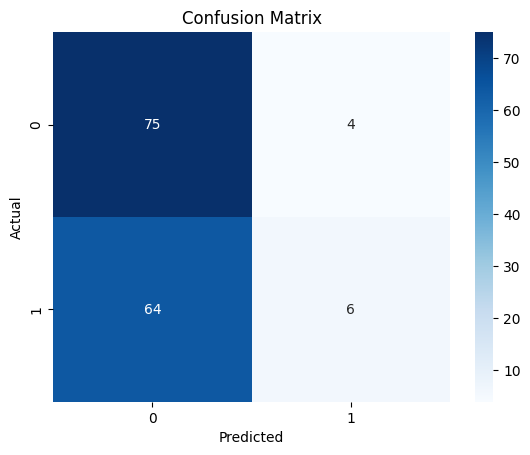

In [44]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
# 2. Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.95      0.69        79
           1       0.60      0.09      0.15        70

    accuracy                           0.54       149
   macro avg       0.57      0.52      0.42       149
weighted avg       0.57      0.54      0.44       149



In [46]:
# 3. Feature Importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})
print(coef_df.sort_values('Coefficient', ascending=False))

                Feature  Coefficient
3  toss_winner_is_team1     0.081985
1             team2_enc    -0.003738
2              city_enc    -0.012784
4          toss_dec_enc    -0.015509
0             team1_enc    -0.016983


# Saving the model

In [47]:
import pickle

# save the model
with open('model.pkl','wb') as f:
  pickle.dump(model,f)

# load and test
with open('model.pkl','rb') as f:
  loaded_model = pickle.load(f)

print("model saved and loaded successfully")

model saved and loaded successfully


# Prediction Function

In [49]:
def predict_winner(team1, team2, city, toss_winner, toss_decision):

    t1 = le_teams.transform([team1])[0]
    t2 = le_teams.transform([team2])[0]
    c  = le_city.transform([city])[0]
    tw = 1 if toss_winner == team1 else 0
    td = le_toss.transform([toss_decision])[0]

    input_data = pd.DataFrame([[t1, t2, c, tw, td]], columns=features)
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0]

    winner = team1 if prediction == 1 else team2
    confidence = max(probability) * 100

    print(f"Predicted Winner : {winner}")
    print(f"Confidence       : {confidence:.1f}%")

# Test
predict_winner(
    team1='Mumbai Indians',
    team2='Chennai Super Kings',
    city='Mumbai',
    toss_winner='Mumbai Indians',
    toss_decision='bat'
)

Predicted Winner : Chennai Super Kings
Confidence       : 57.0%
